In [3]:
import pandas as pd
import numpy as np
import os
import numpy as np
import precession.eccentricity as prececc
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
#function to save a simulation

def archive_bbh_simulation(mass_ratio, chi1, chi2, theta1_0, theta2_0, dphi_0, raw_data, folder="bbh_simulations_archive"):
    
    if not os.path.exists(folder):
        os.makedirs(folder)
    

    time = raw_data['t'].flatten()
    separation = raw_data['a'].flatten()
    th1_rad = raw_data['theta1'].flatten()
    th2_rad = raw_data['theta2'].flatten()
    dphi_rad = raw_data['deltaphi'].flatten()

    m1 = mass_ratio / (1.0 + mass_ratio)
    m2 = 1.0 / (1.0 + mass_ratio)
    

    eff_spin = (m1 * chi1 * np.cos(th1_rad) + m2 * chi2 * np.cos(th2_rad))
    
    
    reduced_mass = (m1 * m2) 
    l_magnitude = reduced_mass * np.sqrt(separation)
    
   
    df = pd.DataFrame({
        'time_M': time,
        'separation_M': separation,
        'angular_momentum_L': l_magnitude,
        'effective_spin_chi_eff': eff_spin,
        'theta1_rad': th1_rad,
        'theta2_rad': th2_rad,
        'deltaphi_rad': dphi_rad
    })
    
 
    th1_deg = int(np.degrees(theta1_0))
    th2_deg = int(np.degrees(theta2_0))
    dp_deg = int(np.degrees(dphi_0))
    
 
    filename = (f"BBH_q:{mass_ratio:.2f}_χ1:{chi1:.2f}_χ2:{chi2:.2f}_"
                f"θ1:{th1_deg}_θ2:{th2_deg}_ΔΦ:{dp_deg}.csv")
    filepath = os.path.join(folder, filename)
    

    header = (f"# BBH Simulation Data - Version 1\n"
              f"# Initial Conditions: q={mass_ratio}, χ1={chi1}, χ2={chi2}, "
              f"θ1_0_deg={th1_deg}, θ2_0_deg={th2_deg}, ΔΦ_0_deg={dp_deg}\n")
    
    with open(filepath, 'w', encoding='utf-8') as f:
        f.write(header)
        df.to_csv(f, index=False, float_format='%.16e')
    

In [28]:
# single simulation whit graphs

q = 1.5
chi1_0 = 0.8
chi2_0 = 0.5
th1_0 = np.pi / 4 
th2_0 = np.pi / 6
dp_0  = np.pi / 2  

a_grid = np.geomspace(100.0, 10.0, 10000)

raw_data = prececc.inspiral_orbav(
    q=q, chi1=chi1_0, chi2=chi2_0,
    theta1=th1_0, theta2=th2_0, deltaphi=dp_0,
    a=a_grid, e=0.0
        )

t_M = raw_data['t'].flatten()
a_M = raw_data['a'].flatten()
theta1_rad = raw_data['theta1'].flatten()
theta2_rad = raw_data['theta2'].flatten()
deltaphi_rad = raw_data['deltaphi'].flatten()

m1 = q / (1.0 + q)
m2 = 1.0 / (1.0 + q)

chi_eff = (m1 * chi1_0 * np.cos(theta1_rad) + m2 * chi2_0 * np.cos(theta2_rad))

L_orbital = (m1 * m2) * np.sqrt(a_M)

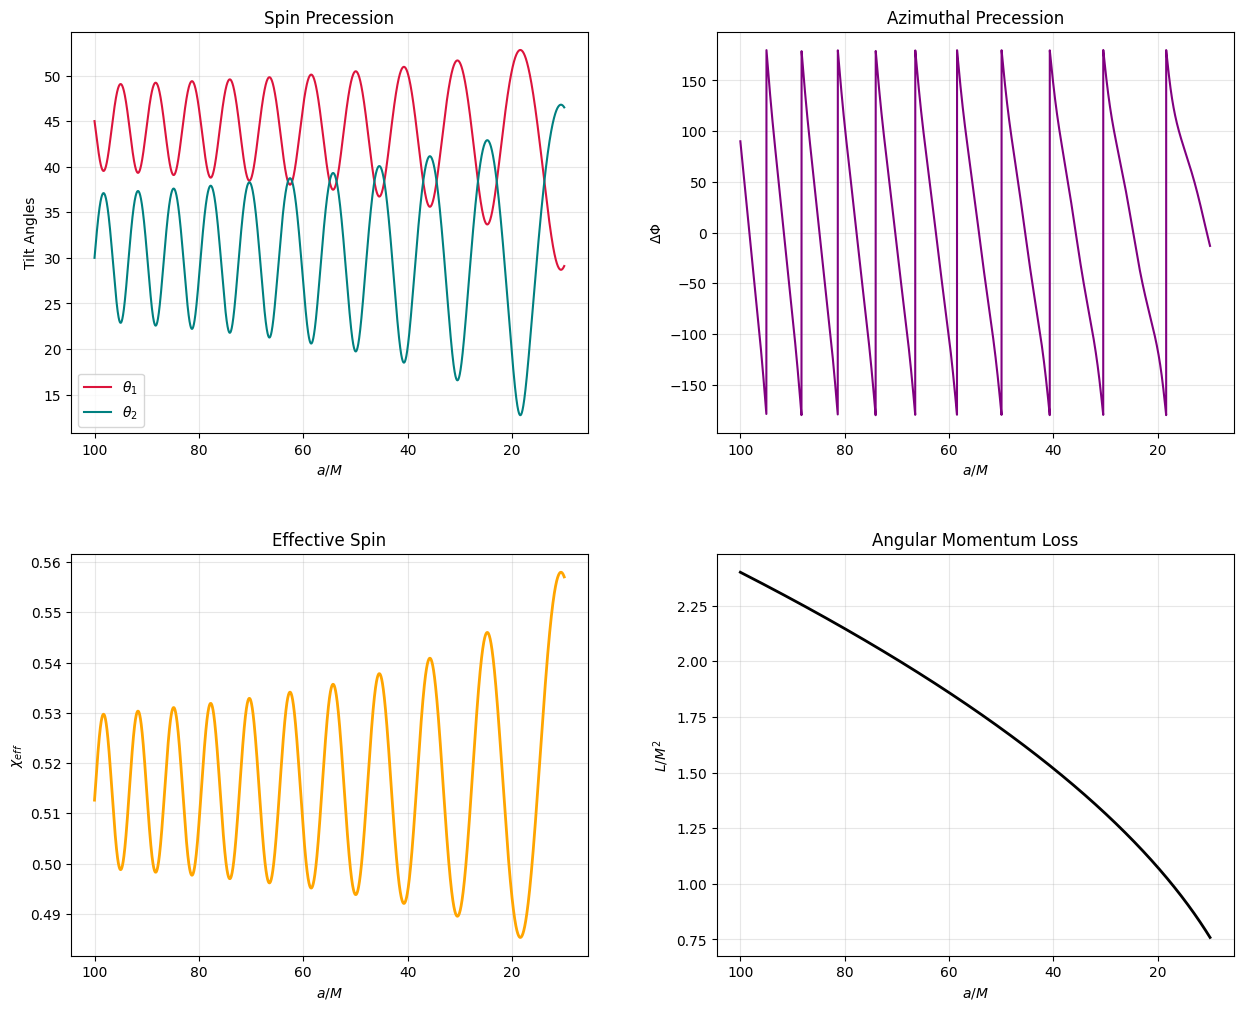

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# spin evolution
axs[0, 0].plot(a_M, np.degrees(theta1_rad), label=r'$\theta_1$', color='crimson', lw=1.5)
axs[0, 0].plot(a_M, np.degrees(theta2_rad), label=r'$\theta_2$', color='teal', lw=1.5)
axs[0, 0].set_xlabel('$a/M$')
axs[0, 0].set_ylabel('Tilt Angles')
axs[0, 0].set_title('Spin Precession')
axs[0, 0].invert_xaxis()
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# deltaphi evolution
axs[0, 1].plot(a_M, np.degrees(deltaphi_rad), color='purple', lw=1.5)
axs[0, 1].set_xlabel('$a/M$')
axs[0, 1].set_ylabel(r'$\Delta\Phi$')
axs[0, 1].set_title('Azimuthal Precession')
axs[0, 1].invert_xaxis()
axs[0, 1].grid(True, alpha=0.3)

# chi_eff evolution
axs[1, 0].plot(a_M, chi_eff, color='orange', lw=2)
axs[1, 0].set_xlabel('$a/M$')
axs[1, 0].set_ylabel(r'$\chi_{eff}$')
axs[1, 0].set_title('Effective Spin')
#axs[1, 0].set_ylim(chi_eff.min()*0.9, chi_eff.max()*1.1) 
axs[1, 0].invert_xaxis()
axs[1, 0].grid(True, alpha=0.3)

# L evolution
axs[1, 1].plot(a_M, L_orbital, color='black', lw=2)
axs[1, 1].set_xlabel('$a/M$')
axs[1, 1].set_ylabel(r'$L/M^2$')
axs[1, 1].set_title('Angular Momentum Loss')
axs[1, 1].invert_xaxis()
axs[1, 1].grid(True, alpha=0.3)

plt.show()

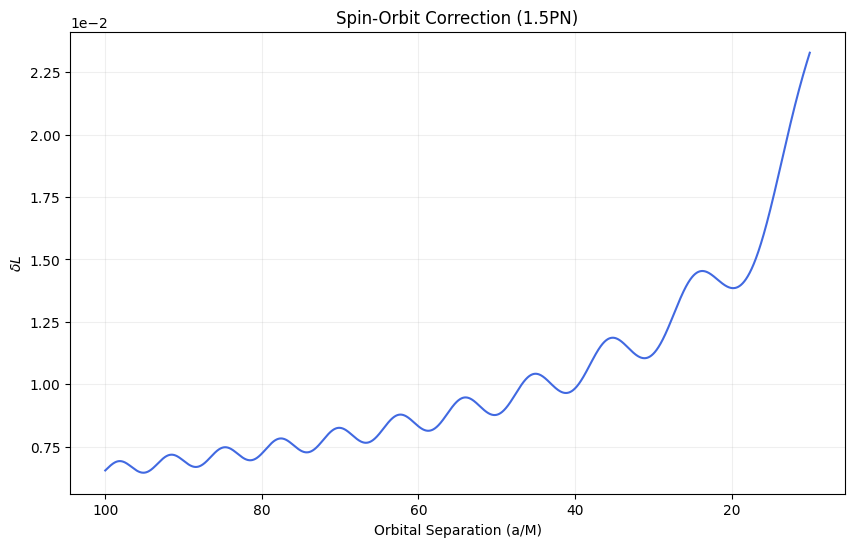

In [39]:
# spin-orbit correction (1.5 PN)
s1_mag = m1**2 * chi1_0
s2_mag = m2**2 * chi2_0

S1_L = s1_mag * np.cos(theta1_rad)
S2_L = s2_mag * np.cos(theta2_rad)
S_tot_L = S1_L + S2_L

cos_gamma = (np.sin(theta1_rad) * np.sin(theta2_rad) * np.cos(deltaphi_rad) + 
             np.cos(theta1_rad) * np.cos(theta2_rad))
s_tot_mag = np.sqrt(s1_mag**2 + s2_mag**2 + 2 * s1_mag * s2_mag * cos_gamma)

L_corrected = L_orbital * (1 + (S_tot_L / a_M))

J_mag = np.sqrt(L_corrected**2 + s_tot_mag**2 + 2 * L_corrected * S_tot_L)

L_residual = L_corrected - L_orbital


plt.figure(figsize=(10, 6))
plt.plot(a_M, L_residual, color='royalblue', lw=1.5)
plt.xlabel('Orbital Separation (a/M)')
plt.ylabel(r'$\delta L$') 
plt.title('Spin-Orbit Correction (1.5PN)')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.gca().invert_xaxis() 
plt.grid(True, alpha=0.2)
plt.show()

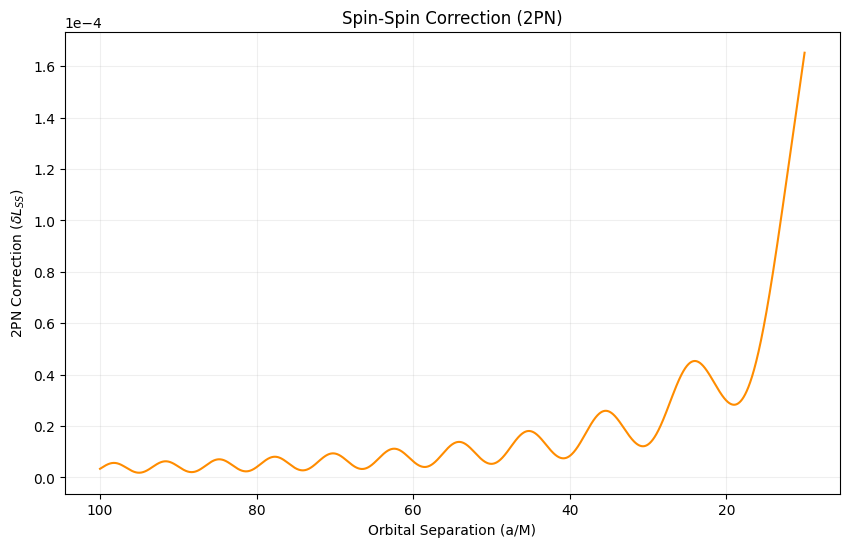

In [41]:
# Spin-Spin correction (2PN)
L_SS_correction = L_orbital * ( (s1_mag * s2_mag * cos_gamma) / (a_M**2) )

plt.figure(figsize=(10, 6))
plt.plot(a_M, L_SS_correction, color='darkorange', lw=1.5)
plt.xlabel('Orbital Separation (a/M)')
plt.ylabel(r'2PN Correction ($\delta L_{SS}$)')
plt.title('Spin-Spin Correction (2PN)')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
#multiple simulations

mass_ratios = [0.4, 0.8]
chi1_values = [0.5, 0.9]

chi2_const = 0.5
th1_0 = np.pi / 4 
th2_0 = np.pi / 4
dp_0  = np.pi / 2  

a_grid = np.geomspace(100.0, 10.0, 1000)


for q in mass_ratios:
    for x1 in chi1_values:
        
        raw_data = prececc.inspiral_orbav(
            q=q, chi1=x1, chi2=chi2_const,
            theta1=th1_0, theta2=th2_0, deltaphi=dp_0,
            a=a_grid, e=0.0
        )
        
        archive_bbh_simulation(
            mass_ratio=q, 
            chi1=x1, 
            chi2=chi2_const, 
            theta1_0=th1_0, 
            theta2_0=th2_0, 
            dphi_0=dp_0, 
            raw_data=raw_data
        )

print("All simulations complete and archived.")


All simulations complete and archived.
